In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


c:\Users\Pradhuman\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


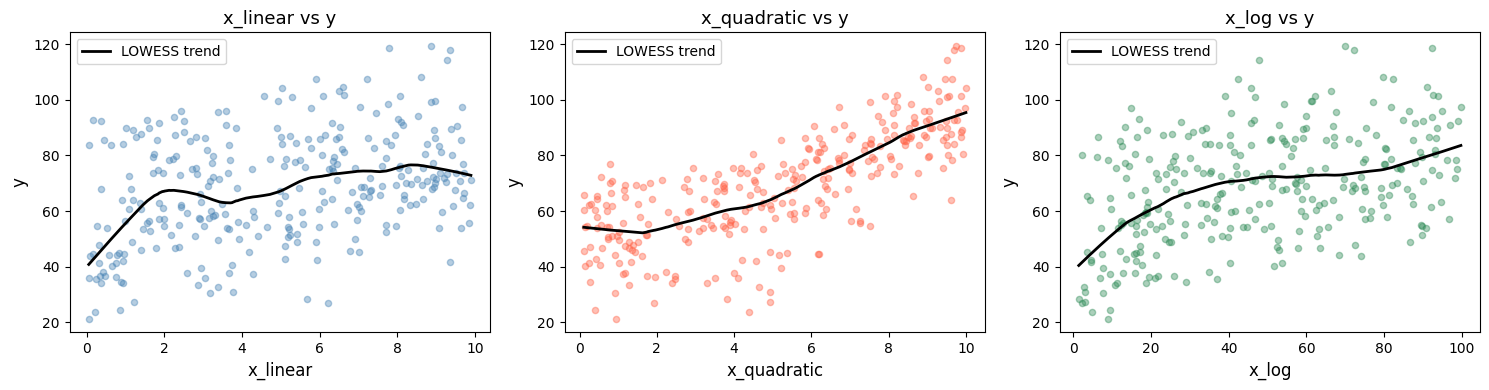

Observation: x_linear → straight trend | x_quadratic → curved | x_log → curved (log shape)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# ── Simulate a dataset with mix of linear and non-linear features ──
np.random.seed(42)
n = 300

X = pd.DataFrame({
    'x_linear'   : np.random.uniform(0, 10, n),          # truly linear relationship
    'x_quadratic': np.random.uniform(0, 10, n),          # y depends on x²
    'x_log'      : np.random.uniform(1, 100, n),         # y depends on log(x)
})

# True underlying relationships
noise = np.random.normal(0, 2, n)
y = (
    3 * X['x_linear']           # linear component
    + 0.5 * X['x_quadratic']**2 # quadratic component
    + 10 * np.log(X['x_log'])   # log component
    + noise
)

# ── Plot each feature vs y ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['x_linear', 'x_quadratic', 'x_log']
colors   = ['steelblue', 'tomato', 'seagreen']

for ax, feat, color in zip(axes, features, colors):
    ax.scatter(X[feat], y, alpha=0.4, color=color, s=20)
    ax.set_xlabel(feat, fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_title(f'{feat} vs y', fontsize=13)
    # Add a LOWESS smoother to see the true trend
    from statsmodels.nonparametric.smoothers_lowess import lowess
    smoothed = lowess(y, X[feat], frac=0.3)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='black', lw=2, label='LOWESS trend')
    ax.legend()

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Observation: x_linear → straight trend | x_quadratic → curved | x_log → curved (log shape)")

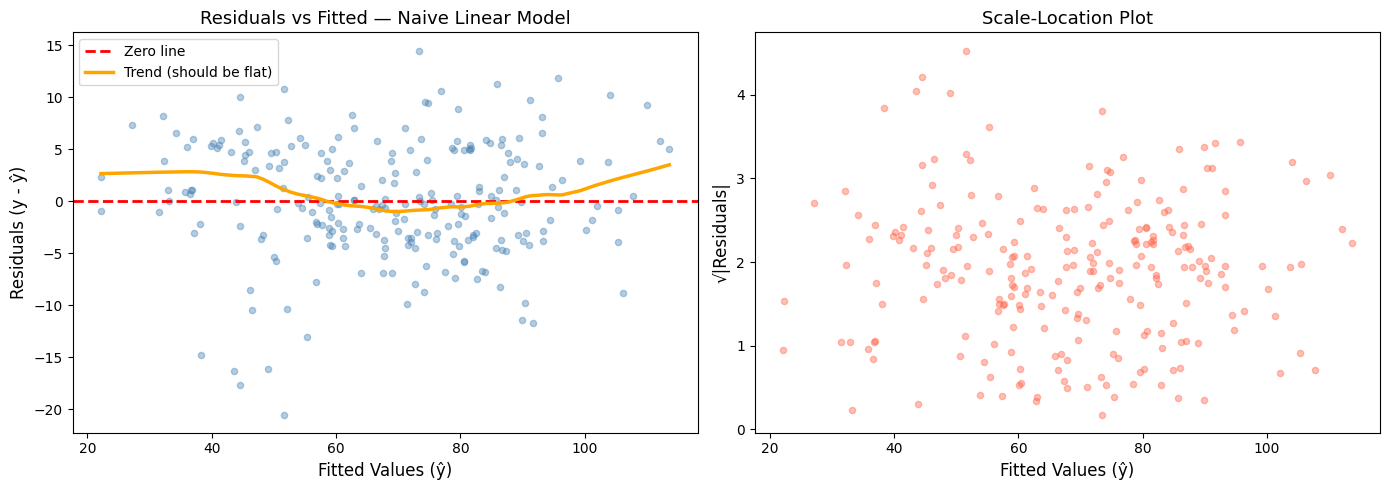

Training R²: 0.9212
If the orange LOWESS line in residuals is NOT flat → linearity is violated.


In [2]:
# ── Fit a naive Linear Regression on all raw features ──
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
residuals = y_train - y_pred_train

# ── Residuals vs Fitted Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Fitted
axes[0].scatter(y_pred_train, residuals, alpha=0.4, color='steelblue', s=20)
axes[0].axhline(0, color='red', linestyle='--', lw=2, label='Zero line')

# Add LOWESS to residuals to see if there's a pattern
smoothed_resid = lowess(residuals, y_pred_train, frac=0.3)
axes[0].plot(smoothed_resid[:, 0], smoothed_resid[:, 1],
             color='orange', lw=2.5, label='Trend (should be flat)')

axes[0].set_xlabel('Fitted Values (ŷ)', fontsize=12)
axes[0].set_ylabel('Residuals (y - ŷ)', fontsize=12)
axes[0].set_title('Residuals vs Fitted — Naive Linear Model', fontsize=13)
axes[0].legend()

# Plot 2: Scale-Location (sqrt of abs residuals — checks homoscedasticity too)
axes[1].scatter(y_pred_train, np.sqrt(np.abs(residuals)), alpha=0.4, color='tomato', s=20)
axes[1].set_xlabel('Fitted Values (ŷ)', fontsize=12)
axes[1].set_ylabel('√|Residuals|', fontsize=12)
axes[1].set_title('Scale-Location Plot', fontsize=13)

plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training R²: {r2_score(y_train, y_pred_train):.4f}")
print("If the orange LOWESS line in residuals is NOT flat → linearity is violated.")

In [3]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_harvey_collier

# Statsmodels requires adding an intercept manually
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Harvey-Collier test — tests if recursive residuals have zero mean
# H0: Linearity holds | H1: Non-linearity present
try:
    hc_t, hc_p = linear_harvey_collier(ols_model)
    print(f"Harvey-Collier Test → t-stat: {hc_t:.4f}, p-value: {hc_p:.6f}")
    if hc_p < 0.05:
        print("❌ p < 0.05: Reject H₀ — Evidence of NON-LINEARITY in the model")
    else:
        print("✅ p ≥ 0.05: Fail to reject H₀ — No significant evidence against linearity")
except Exception as e:
    print(f"Test note: {e}")

# Also print the full statsmodels summary for context
print("\n--- OLS Summary (key parts) ---")
print(ols_model.summary().tables[0])

Harvey-Collier Test → t-stat: 0.0905, p-value: 0.927973
✅ p ≥ 0.05: Fail to reject H₀ — No significant evidence against linearity

--- OLS Summary (key parts) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     919.1
Date:                Thu, 14 May 2026   Prob (F-statistic):          7.76e-130
Time:                        00:17:10   Log-Likelihood:                -751.84
No. Observations:                 240   AIC:                             1512.
Df Residuals:                     236   BIC:                             1526.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         


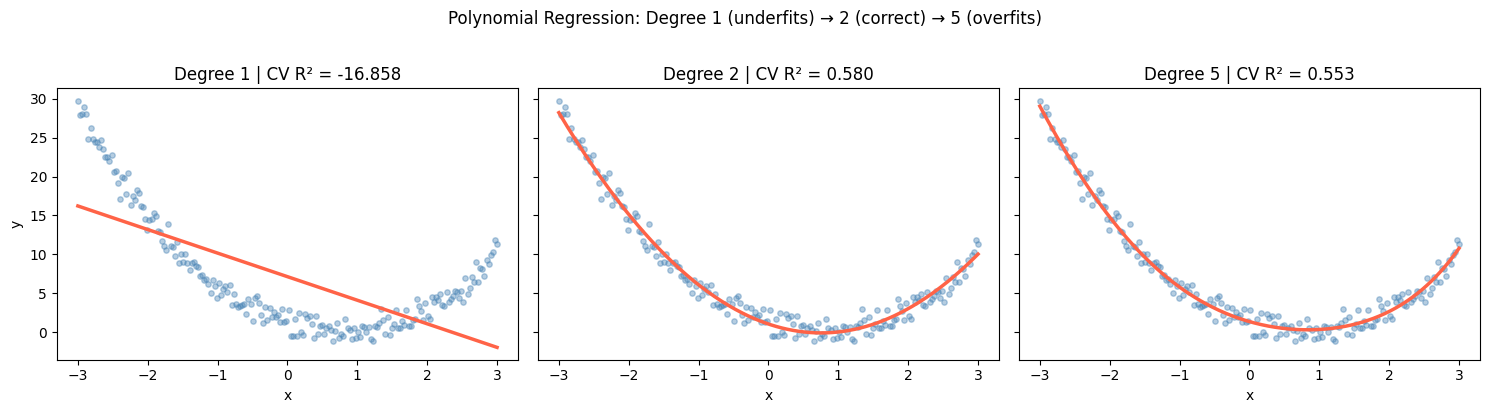

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Simulate a purely quadratic 1D dataset for clean visualization
np.random.seed(0)
x_1d = np.linspace(-3, 3, 200)
y_1d = 2 * x_1d**2 - 3 * x_1d + 1 + np.random.normal(0, 1, 200)

X_1d = x_1d.reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
degrees = [1, 2, 5]

for ax, deg in zip(axes, degrees):
    # Pipeline: PolynomialFeatures → LinearRegression
    poly_pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('lr',   LinearRegression())
    ])
    poly_pipeline.fit(X_1d, y_1d)
    
    # Generate smooth prediction curve
    x_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
    y_plot = poly_pipeline.predict(x_plot)
    
    cv_r2 = cross_val_score(poly_pipeline, X_1d, y_1d, cv=5, scoring='r2').mean()
    
    ax.scatter(x_1d, y_1d, alpha=0.4, s=15, color='steelblue')
    ax.plot(x_plot, y_plot, color='tomato', lw=2.5)
    ax.set_title(f'Degree {deg} | CV R² = {cv_r2:.3f}', fontsize=12)
    ax.set_xlabel('x')

axes[0].set_ylabel('y')
plt.suptitle('Polynomial Regression: Degree 1 (underfits) → 2 (correct) → 5 (overfits)', 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('polynomial_regression.png', dpi=150, bbox_inches='tight')
plt.show()

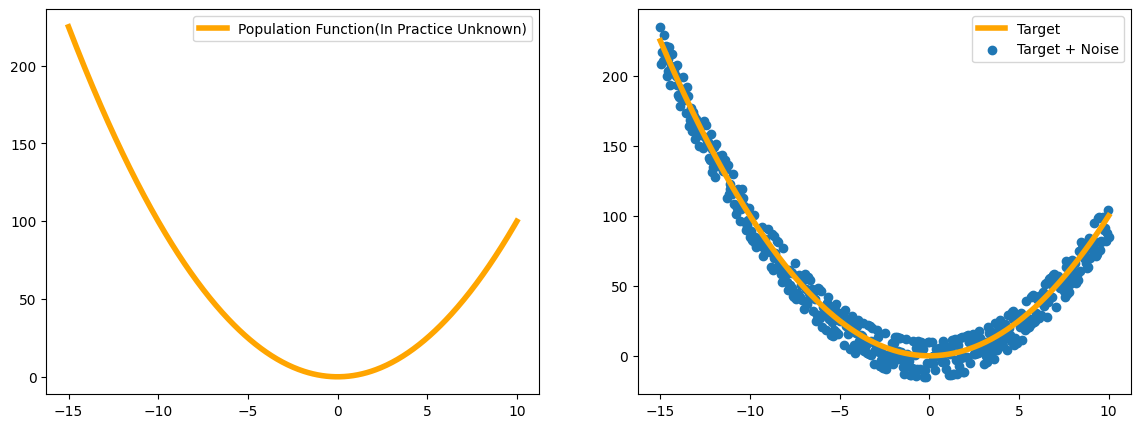

In [ ]:
x = np.linspace(-15,10,500)
y = x**2

y_noised = x**2 + 5*np.random.randint(-3,3,500)
fig , ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(x,y , label = 'Population Function(In Practice Unknown)',color = 'orange',linewidth=4)
ax[1].plot(x,y , label = 'Target',color = 'orange',linewidth=4)
ax[1].scatter(x,y_noised , label='Target + Noise')
ax[0].legend()
ax[1].legend()
plt.show()